In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


chargement et redimensionnement des images

In [ ]:
import os
from PIL import Image
from tqdm import tqdm

def resize_images(source_dir, target_dir, size=(100, 100)):
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)

    # Compte le nombre total de fichiers .jpg, .jpeg, .png
    total = sum(
        len([f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png"))])
        for _, _, files in os.walk(source_dir)
    )

    progress = tqdm(total=total, desc="Redimensionnement des images")

    for root, dirs, files in os.walk(source_dir):
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                try:
                    img_path = os.path.join(root, file)
                    img = Image.open(img_path)
                    img_resized = img.resize(size)

                    # Chemin de sauvegarde
                    relative_path = os.path.relpath(root, source_dir)
                    save_dir = os.path.join(target_dir, relative_path)
                    os.makedirs(save_dir, exist_ok=True)

                    img_resized.save(os.path.join(save_dir, file))
                    progress.update(1)
                except Exception as e:
                    print(f"Erreur avec {file} : {e}")

    progress.close()



redimensionnement des images d'entraînement

In [ ]:

resize_images(
    source_dir="/content/drive/MyDrive/fruits-360_original-size/fruits-360-original-size/Training",
    target_dir="/content/drive/MyDrive/fruits-360_100x100/Training",
    size=(100, 100)
)


Redimensionnement des images: 100%|██████████| 29222/29222 [2:29:15<00:00,  3.26it/s]


redimensionnement des images de test

In [ ]:
resize_images(
    source_dir="/content/drive/MyDrive/fruits-360_original-size/fruits-360-original-size/Test",
    target_dir="/content/drive/MyDrive/fruits-360_100x100/Test",
    size=(100, 100)

)

Redimensionnement des images: 100%|██████████| 14527/14527 [1:13:24<00:00,  3.30it/s]


verification des sous dossiers générés après redimensionnement

In [ ]:
print("Sous-dossiers générés :", os.listdir("/content/drive/MyDrive/fruits-360_100x100/Training")[:5])

Sous-dossiers générés : ['Tomato Cherry Maroon 1', 'Tomato 8', 'Tomato Maroon 2', 'Tomato Cherry Orange 1', 'Tomato 7']


affiche nombre total de classes dans le  dossier training

In [ ]:
import os

train_dir = "/content/drive/MyDrive/fruits-360_100x100/Training"
classes = sorted(os.listdir(train_dir))
print(f"Nombre de classes : {len(classes)}")

for cls in classes[:10]:
    path = os.path.join(train_dir, cls)
    nb_images = len([f for f in os.listdir(path) if f.endswith(('.jpg', '.jpeg', '.png'))])
    print(f"{cls} : {nb_images} images")



Nombre de classes : 90
Apple 10 : 465 images
Apple 11 : 287 images
Apple 12 : 310 images
Apple 13 : 465 images
Apple 14 : 310 images
Apple 17 : 489 images
Apple 18 : 326 images
Apple 19 : 486 images
Apple 5 : 294 images
Apple 7 : 462 images


affiche nombre total de classes dans le  dossier test

In [ ]:
import os

test_dir = "/content/drive/MyDrive/fruits-360_100x100/Test"
classes = sorted(os.listdir(test_dir))
print(f"Nombre de classes (test) : {len(classes)}")

for cls in classes[:10]:
    path = os.path.join(test_dir, cls)
    nb_images = len([f for f in os.listdir(path) if f.endswith(('.jpg', '.jpeg', '.png'))])
    print(f"{cls} : {nb_images} images")


Nombre de classes (test) : 90
Apple 10 : 231 images
Apple 11 : 142 images
Apple 12 : 154 images
Apple 13 : 231 images
Apple 14 : 154 images
Apple 17 : 243 images
Apple 18 : 162 images
Apple 19 : 241 images
Apple 5 : 146 images
Apple 7 : 229 images


verification de l'intégralité des images dans les dossiers training et test

In [ ]:
from PIL import Image

def check_images_quality(directory):
    bad_files = [] # Liste pour stocker les fichiers corrompus
    count = 0  # Compteur d'images valides

    for root, _, files in os.walk(directory):  # Parcours de tous les fichiers du dossier
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                path = os.path.join(root, file)
                try:
                    img = Image.open(path) # Ouvre l'image
                    img.verify()  # Vérifie si l'image est lisible
                    count += 1    # Incrémente si image OK
                except Exception as e:
                    bad_files.append((path, str(e)))  # Sinon, ajoute à la liste des corrompues

    print(f"Total images valides : {count}")
    print(f"Images corrompues : {len(bad_files)}")
    if bad_files:
        print("Exemples :", bad_files[:3]) # Affiche quelques exemples si jamais il y a des erreurs

# Lancer la vérification sur Training et Test
check_images_quality(train_dir)
check_images_quality(test_dir)

Total images valides : 29222
Images corrompues : 0
Total images valides : 14527
Images corrompues : 0


Afficher quelques images pour voir la qualité visuelle


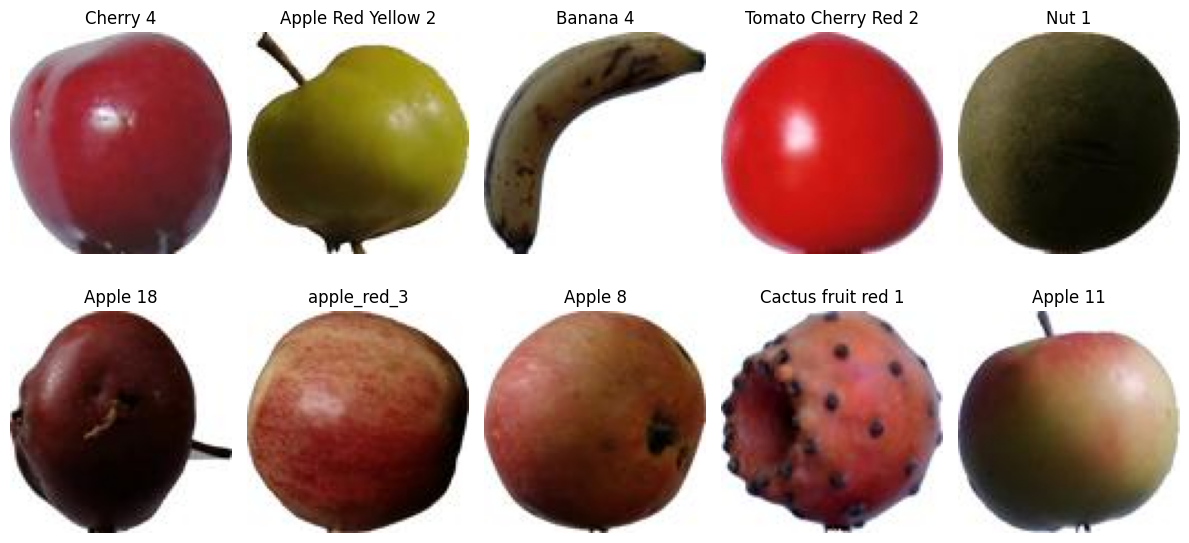

In [ ]:
import os, random
import matplotlib.pyplot as plt
from PIL import Image

# Dossier contenant les images redimensionnées
train_dir = "/content/drive/MyDrive/fruits-360_100x100/Training"

# Sélection de 10 classes aléatoires dans le dossier Training
classes = random.sample(os.listdir(train_dir), 10)

plt.figure(figsize=(12, 6))  # Taille de la figure (2 lignes, 5 colonnes)

# Parcours des 10 classes
for i, cls in enumerate(classes):
    # Chemin complet d'une image aléatoire dans la classe
    img_path = os.path.join(train_dir, cls, random.choice(os.listdir(os.path.join(train_dir, cls))))

    # Ouverture de l'image
    img = Image.open(img_path)

    # Affichage dans une grille 2×5
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(cls, fontsize=12)  # Affiche le nom de la classe
    plt.axis("off")  # Supprime les axes

plt.tight_layout()  # Ajuste les espacements
plt.show()  # Affiche toutes les images




Normalisation des images et création des générateurs d'images(ImageDataGenerator)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Générateur d'images pour l'entraînement avec normalisation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,        # rotation jusqu'à 20°
    zoom_range=0.2,# zoom jusqu'à 20%
    width_shift_range=0.2,          # Décale l’image horizontalement jusqu’à 20% de sa largeur
    height_shift_range=0.2,         # Décale l’image verticalement jusqu’à 20% de sa hauteur
    horizontal_flip=True,     # retournement horizontal
     fill_mode='nearest'             # Remplit les pixels vides après transformation avec les plus proches
)

# Création du générateur d'entraînement
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(100, 100), # la taille des images redimensionnées
    batch_size=32,
    class_mode='categorical'
)

# Générateur d'images pour la validation/test avec normalisation
test_datagen = ImageDataGenerator(rescale=1./255)

# Création du générateur de validation/test AVEC les mêmes classes
validation_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(100, 100),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 29221 images belonging to 90 classes.
Found 14527 images belonging to 90 classes.


création du modèle CNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

# Convolution + ReLU + MaxPooling
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(100, 100, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Deuxième bloc convolution
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Troisième bloc convolution
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten et Fully Connected
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))  # pour éviter le surapprentissage
model.add(Dense(90, activation='softmax'))  # 90 classes

# Résumé du modèle
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 90)             │        11,610 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,743,386 (6.65 MB)

 Trainable params: 1,743,386 (6.65 MB)

 Non-trainable params: 0 (0.00 B)

Compilation du modèle

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Entraînement du modèle

In [ ]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
914/914 ━━━━━━━━━━━━━━━━━━━━ 860s 935ms/step - accuracy: 0.1281 - loss: 3.5600 - val_accuracy: 0.7082 - val_loss: 0.9002
Epoch 2/10
914/914 ━━━━━━━━━━━━━━━━━━━━ 745s 814ms/step - accuracy: 0.5168 - loss: 1.4527 - val_accuracy: 0.8510 - val_loss: 0.4092
Epoch 3/10
914/914 ━━━━━━━━━━━━━━━━━━━━ 748s 818ms/step - accuracy: 0.6297 - loss: 1.0573 - val_accuracy: 0.8733 - val_loss: 0.3697
Epoch 4/10
914/914 ━━━━━━━━━━━━━━━━━━━━ 739s 809ms/step - accuracy: 0.6845 - loss: 0.8802 - val_accuracy: 0.8972 - val_loss: 0.2747
Epoch 5/10
914/914 ━━━━━━━━━━━━━━━━━━━━ 744s 811ms/step - accuracy: 0.7216 - loss: 0.7757 - val_accuracy: 0.9360 - val_loss: 0.1885
Epoch 6/10
914/914 ━━━━━━━━━━━━━━━━━━━━ 753s 824ms/step - accuracy: 0.7595 - loss: 0.6669 - val_accuracy: 0.9446 - val_loss: 0.1447
Epoch 7/10
914/914 ━━━━━━━━━━━━━━━━━━━━ 748s 819ms/step - accuracy: 0.7767 - loss: 0.6134 - val_accuracy: 0.9502 - val_loss: 0.1431
Epoch 8/10
914/914 ━━━━━━━━━━━━━━━━━━━━ 752s 823ms/step - accuracy: 0.7932 -

Affiche les courbes d'apprentissage

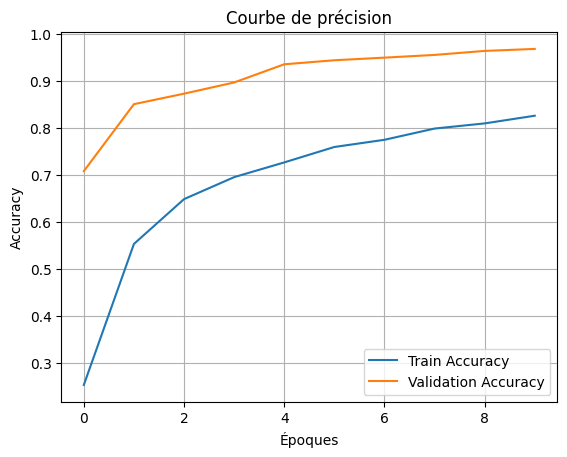

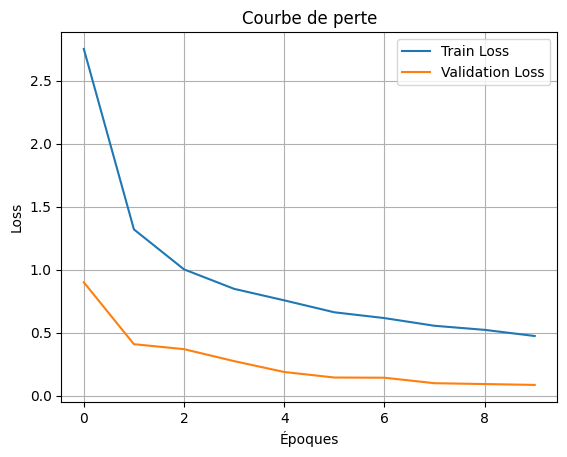

In [ ]:
import matplotlib.pyplot as plt

# Courbe de précision
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Courbe de précision')
plt.xlabel('Époques')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Courbe de perte
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Courbe de perte')
plt.xlabel('Époques')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


creation du dossier

In [ ]:
import os

# Chemin vers le dossier "models" dans Drive
drive_models_path = "/content/drive/MyDrive/models"

# Créer le dossier si besoin
os.makedirs(drive_models_path, exist_ok=True)


enregistremet du  modèle

In [ ]:
model.save(drive_models_path + "/fruit_model.h5")

enregistre de l'historique d'entraînement du modèle

In [ ]:
import pickle

with open(os.path.join(drive_models_path, 'history.pkl'), 'wb') as f:
    pickle.dump(history.history, f)


evaluation du modèle sur les données de validation et affichage de la precision et de la perte

In [ ]:
test_loss, test_accuracy = model.evaluate(validation_generator)
print(f"Accuracy sur les données de test : {test_accuracy:.4f}")
print(f"Loss sur les données de test : {test_loss:.4f}")


454/454 ━━━━━━━━━━━━━━━━━━━━ 107s 236ms/step - accuracy: 0.9815 - loss: 0.0585
Accuracy sur les données de test : 0.9687
Loss sur les données de test : 0.0859


In [ ]:
import pickle
import os

# Chemin du fichier history.pkl sauvegardé (adapter à ton dossier Drive)
history_path = "/content/drive/MyDrive/models/history.pkl"

# Charger l'historique
with open(history_path, 'rb') as f:
    history_loaded = pickle.load(f)

print("Historique chargé avec succès.")

Historique chargé avec succès.


In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/models/fruit_model.h5')

In [ ]:
import numpy as np
Y_pred = model.predict(validation_generator)
y_pred = np.argmax(Y_pred, axis=1)  # Prédictions finales


454/454 ━━━━━━━━━━━━━━━━━━━━ 4320s 10s/step


In [ ]:
y_true = validation_generator.classes
class_labels = list(validation_generator.class_indices.keys())

Affichage de la matrice de confusion

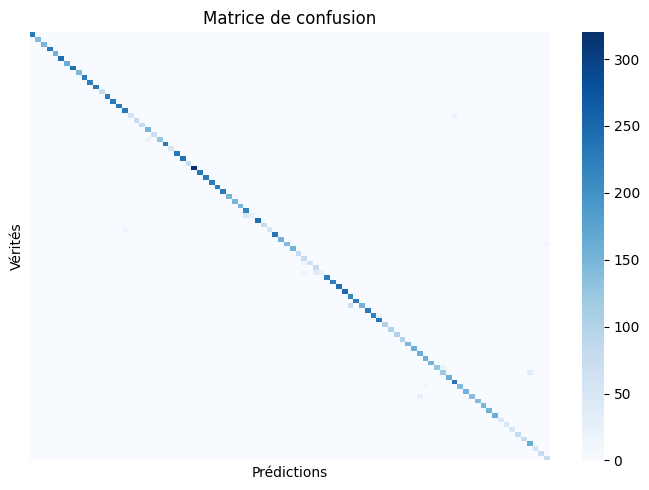

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, cmap="Blues", xticklabels= False, yticklabels= False)
plt.title("Matrice de confusion")
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.tight_layout()
plt.show()


Affichage du rapport de classification

In [ ]:
from sklearn.metrics import classification_report

print("Rapport de classification :\n")
print(classification_report(y_true, y_pred, target_names=class_labels))


Rapport de classification :

                           precision    recall  f1-score   support

                 Apple 10       0.98      0.99      0.99       231
                 Apple 11       0.99      1.00      1.00       142
                 Apple 12       0.97      0.97      0.97       154
                 Apple 13       0.98      1.00      0.99       231
                 Apple 14       1.00      1.00      1.00       154
                 Apple 17       1.00      1.00      1.00       243
                 Apple 18       1.00      1.00      1.00       162
                 Apple 19       0.98      1.00      0.99       241
                  Apple 5       1.00      1.00      1.00       146
                  Apple 7       1.00      0.99      0.99       229
                  Apple 8       0.99      0.98      0.99       228
                  Apple 9       0.93      1.00      0.96       231
             Apple Core 1       1.00      1.00      1.00        78
       Apple Red Yellow 2       

sauvegarde de la matrice de confusion sous forme d'image

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap="Blues", xticklabels=False, yticklabels=False)
plt.title("Matrice de confusion")
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/models/matrice_confusion.png')
plt.close()


sauvegarde du rapport de classification dans un fichier texte

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=class_labels)
with open('/content/drive/MyDrive/models/rapport_classification.txt', 'w') as f:
    f.write(report)

sauvegarde des courbes d'apprentissage

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Courbes d'apprentissage")
plt.xlabel("Épochs")
plt.ylabel("Valeurs")
plt.legend()
plt.grid()
plt.savefig('/content/drive/MyDrive/models/courbe_apprentissage.png')
plt.close()


In [ ]:
import os
os.chdir('/content/drive/MyDrive/models')
os.listdir()


['fruit_model.h5',
 'history.pkl',
 'matrice_confusion.png',
 'rapport_classification.txt',
 'courbe_apprentissage.png',
 'history_mobilenet.pkl',
 'mobilenet_v2_best.h5',
 'history_mobilenet_resume.pkl',
 'mobilenet_v2_finetuned.h5',
 'classes.json']

In [ ]:
import os
os.chdir('/content/drive/MyDrive/fruit_project/models')
os.listdir()

['history_mobilenet.pkl',
 'history_mobilenet_finetune.pkl',
 'mobilenet_v2_finetuned.keras',
 'mobilenet_v2_finetuned.h5']

In [ ]:
from tensorflow.keras.models import load_model

cnn_model = load_model('fruit_model.h5')


In [ ]:
loss, acc = cnn_model.evaluate(validation_generator)  # ou test_generator
print(f"Accuracy: {acc:.4f}  |  Loss: {loss:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


454/454 ━━━━━━━━━━━━━━━━━━━━ 8482s 19s/step - accuracy: 0.9815 - loss: 0.0585
Accuracy: 0.9687  |  Loss: 0.0859


In [ ]:
import os
from PIL import Image, ImageFile
import shutil

ImageFile.LOAD_TRUNCATED_IMAGES = True  # tolérer certains JPEG tronqués

def quarantine_bad_images(root_dir, quarantine_root):
    os.makedirs(quarantine_root, exist_ok=True)
    bad_files = []

    for root, _, files in os.walk(root_dir):
        for f in files:
            if not f.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            src = os.path.join(root, f)
            # chemin relatif pour reproduire la structure côté quarantaine
            rel = os.path.relpath(src, root_dir)
            dst = os.path.join(quarantine_root, rel)
            dst_dir = os.path.dirname(dst)
            try:
                with Image.open(src) as im:
                    im.verify()
                with Image.open(src) as im2:
                    im2.load()
            except Exception:
                bad_files.append(src)
                os.makedirs(dst_dir, exist_ok=True)
                try:
                    shutil.move(src, dst)
                except Exception as mv_e:
                    print(f"[WARN] Impossible de déplacer {src} -> {dst}: {mv_e}")
    return bad_files

# Dossiers
train_dir = "/content/drive/MyDrive/fruits-360_100x100/Training"
test_dir  = "/content/drive/MyDrive/fruits-360_100x100/Test"

# Quarantaine HORS des dossiers train/test
train_quarantine = "/content/drive/MyDrive/fruits-360_100x100/_quarantine_train"
test_quarantine  = "/content/drive/MyDrive/fruits-360_100x100/_quarantine_test"

bad_train = quarantine_bad_images(train_dir, train_quarantine)
bad_test  = quarantine_bad_images(test_dir,  test_quarantine)

print(f"Fichiers corrompus déplacés (train): {len(bad_train)}")
print(f"Fichiers corrompus déplacés (test) : {len(bad_test)}")
print("Exemples train:", bad_train[:5])
print("Exemples test :", bad_test[:5])


Fichiers corrompus déplacés (train): 1
Fichiers corrompus déplacés (test) : 0
Exemples train: ['/content/drive/MyDrive/fruits-360_100x100/Training/Tomato 8/_bad/_bad/r0_0.jpg']
Exemples test : []


In [ ]:
import os

def remove_empty_bad_dirs(root_dir, bad_name="_bad"):
    for root, dirs, files in os.walk(root_dir, topdown=False):
        for d in dirs:
            if d == bad_name:
                full = os.path.join(root, d)
                if not os.listdir(full):  # dossier vide
                    os.rmdir(full)
                    print("Supprimé dossier vide :", full)

remove_empty_bad_dirs(train_dir)
remove_empty_bad_dirs(test_dir)


Supprimé dossier vide : /content/drive/MyDrive/fruits-360_100x100/Training/Tomato 8/_bad/_bad
Supprimé dossier vide : /content/drive/MyDrive/fruits-360_100x100/Training/Tomato 8/_bad


recharge du dataset et creation du modèle MobileNetV2

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


IMG_SIZE = (128, 128)
BATCH    = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20, zoom_range=0.2,
    width_shift_range=0.2, height_shift_range=0.2,
    horizontal_flip=True, fill_mode='nearest'
)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH, class_mode='categorical'
)
validation_generator = val_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH, class_mode='categorical', shuffle=False
)

Found 29221 images belonging to 90 classes.
Found 14527 images belonging to 90 classes.


In [ ]:
# ===  génération du fichier classes.json ===
import json, os

idx_to_class = {v: k for k, v in validation_generator.class_indices.items()}

classes_path = "/content/drive/MyDrive/models/classes.json"
os.makedirs(os.path.dirname(classes_path), exist_ok=True)
with open(classes_path, "w") as f:
    json.dump({str(k): v for k, v in idx_to_class.items()}, f, ensure_ascii=False, indent=2)

print("✅ Fichier classes.json sauvegardé :", classes_path)


✅ Fichier classes.json sauvegardé : /content/drive/MyDrive/models/classes.json


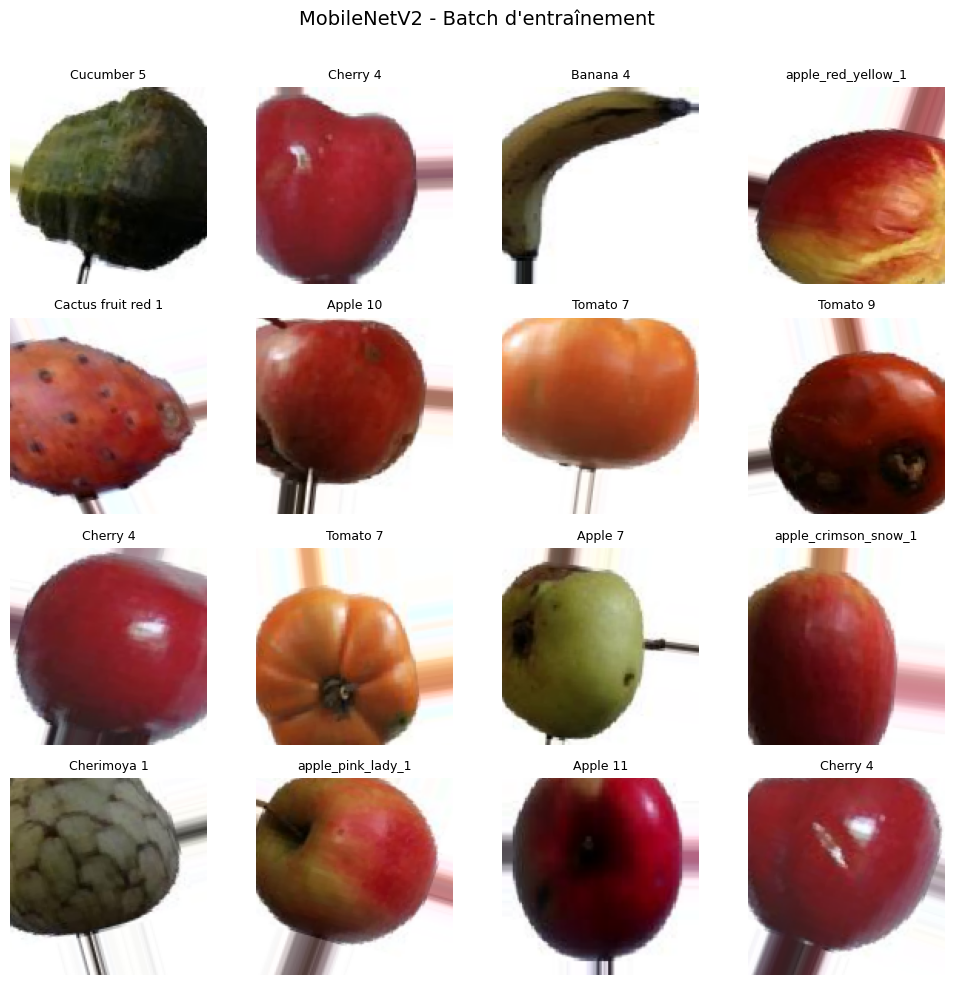

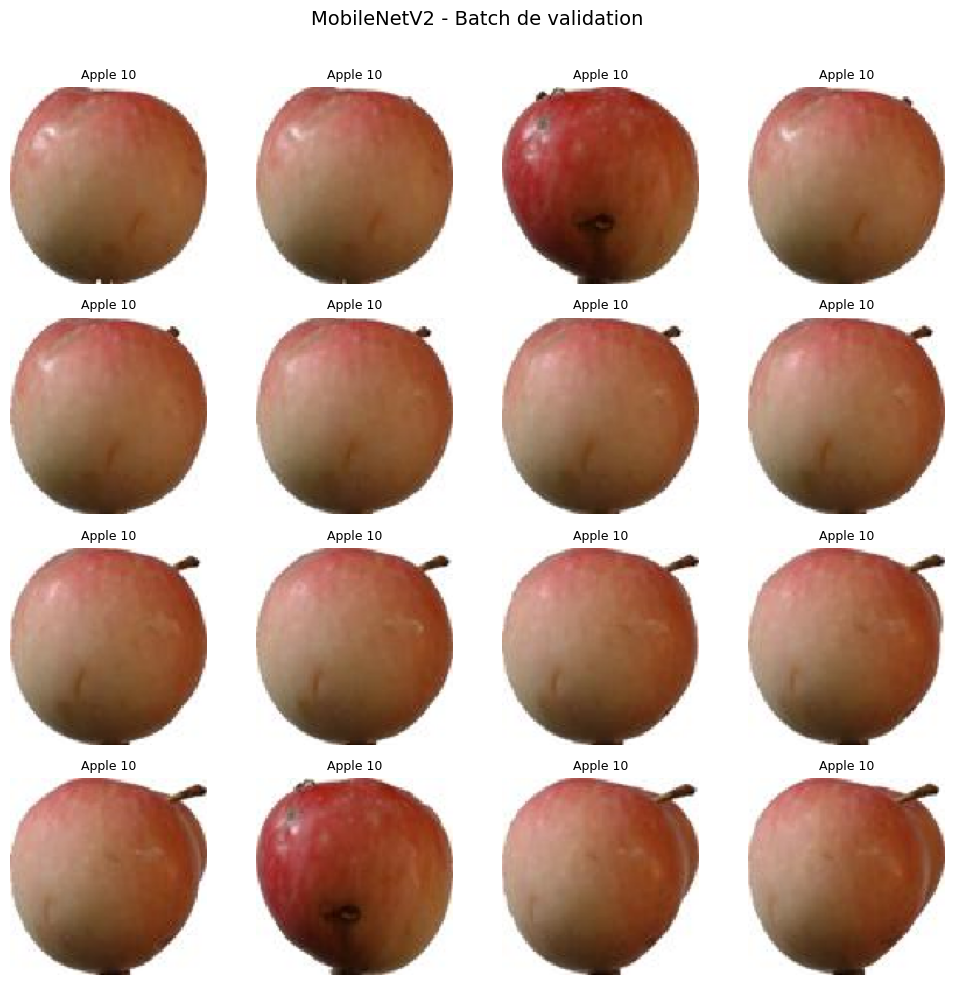

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Map index -> nom de classe
idx_to_class = {v: k for k, v in train_generator.class_indices.items()}

def show_batch(generator, n=16, title="Exemples d'images (après prétraitement)"):
    """
    Affiche n images d'un batch avec leurs labels (noms de classes).
    Compatible avec MobileNetV2 (preprocess_input -> pixels [-1,1]).
    """
    # Récupère un batch
    x_batch, y_batch = next(generator)  # x: (B, H, W, 3), y: one-hot (B, num_classes)
    b = min(n, x_batch.shape[0])

    # Dé-normalisation spéciale MobileNetV2: [-1,1] -> [0,255]
    x_vis = (x_batch[:b] * 127.5 + 127.5).clip(0, 255).astype("uint8")

    # Labels en texte
    y_idx = np.argmax(y_batch[:b], axis=1)
    y_names = [idx_to_class[i] for i in y_idx]

    # Affichage en grille
    cols = int(np.ceil(np.sqrt(b)))
    rows = int(np.ceil(b / cols))
    plt.figure(figsize=(2.5*cols, 2.5*rows))
    plt.suptitle(title, fontsize=14)
    for i in range(b):
        ax = plt.subplot(rows, cols, i + 1)
        plt.imshow(x_vis[i])
        ax.set_title(y_names[i], fontsize=9)
        ax.axis("off")
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# --- Utilisation ---
# Sur le train
show_batch(train_generator, n=16, title="MobileNetV2 - Batch d'entraînement")

# Sur le test/validation
show_batch(validation_generator, n=16, title="MobileNetV2 - Batch de validation")


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
base_model.trainable = False  # tête gelee seule

mobilenet_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(train_generator.num_classes, activation='softmax')
])


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
mobilenet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 90)             │        11,610 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,433,562 (9.28 MB)

 Trainable params: 175,578 (685.85 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

mobilenet_model.compile(optimizer=Adam(1e-4),
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

ckpt = ModelCheckpoint("mobilenet_v2_best.h5", monitor="val_accuracy",
                       save_best_only=True, mode="max", verbose=1)
early = EarlyStopping(monitor="val_accuracy", patience=5,
                      restore_best_weights=True, verbose=1)
rlr = ReduceLROnPlateau(monitor="val_loss", factor=0.3,
                         patience=3, min_lr=1e-6, verbose=1)


entraînement (tete seule)

In [ ]:
history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[ckpt, early, rlr],
    verbose=1
)


Epoch 1/20
914/914 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.5467 - loss: 1.6735
Epoch 1: val_accuracy improved from -inf to 0.82901, saving model to mobilenet_v2_best.h5


914/914 ━━━━━━━━━━━━━━━━━━━━ 2684s 3s/step - accuracy: 0.5467 - loss: 1.6733 - val_accuracy: 0.8290 - val_loss: 0.9021 - learning_rate: 1.0000e-04
Epoch 2/20
914/914 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 0.6789 - loss: 1.1155
Epoch 2: val_accuracy improved from 0.82901 to 0.89165, saving model to mobilenet_v2_best.h5


914/914 ━━━━━━━━━━━━━━━━━━━━ 722s 790ms/step - accuracy: 0.6790 - loss: 1.1154 - val_accuracy: 0.8917 - val_loss: 0.6185 - learning_rate: 1.0000e-04
Epoch 3/20
914/914 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.7516 - loss: 0.8528
Epoch 3: val_accuracy improved from 0.89165 to 0.91003, saving model to mobilenet_v2_best.h5


914/914 ━━━━━━━━━━━━━━━━━━━━ 716s 784ms/step - accuracy: 0.7516 - loss: 0.8527 - val_accuracy: 0.9100 - val_loss: 0.4866 - learning_rate: 1.0000e-04
Epoch 4/20
914/914 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - accuracy: 0.7914 - loss: 0.6959
Epoch 4: val_accuracy improved from 0.91003 to 0.92717, saving model to mobilenet_v2_best.h5


914/914 ━━━━━━━━━━━━━━━━━━━━ 708s 775ms/step - accuracy: 0.7914 - loss: 0.6959 - val_accuracy: 0.9272 - val_loss: 0.3846 - learning_rate: 1.0000e-04
Epoch 5/20
914/914 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - accuracy: 0.8242 - loss: 0.5922
Epoch 5: val_accuracy improved from 0.92717 to 0.93474, saving model to mobilenet_v2_best.h5


914/914 ━━━━━━━━━━━━━━━━━━━━ 718s 786ms/step - accuracy: 0.8242 - loss: 0.5922 - val_accuracy: 0.9347 - val_loss: 0.3279 - learning_rate: 1.0000e-04
Epoch 6/20
914/914 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.8390 - loss: 0.5218
Epoch 6: val_accuracy improved from 0.93474 to 0.94169, saving model to mobilenet_v2_best.h5


914/914 ━━━━━━━━━━━━━━━━━━━━ 717s 785ms/step - accuracy: 0.8390 - loss: 0.5218 - val_accuracy: 0.9417 - val_loss: 0.2894 - learning_rate: 1.0000e-04
Epoch 7/20
914/914 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.8629 - loss: 0.4569
Epoch 7: val_accuracy improved from 0.94169 to 0.94610, saving model to mobilenet_v2_best.h5


914/914 ━━━━━━━━━━━━━━━━━━━━ 705s 770ms/step - accuracy: 0.8629 - loss: 0.4569 - val_accuracy: 0.9461 - val_loss: 0.2553 - learning_rate: 1.0000e-04
Epoch 8/20
914/914 ━━━━━━━━━━━━━━━━━━━━ 0s 545ms/step - accuracy: 0.8779 - loss: 0.4061
Epoch 8: val_accuracy improved from 0.94610 to 0.95064, saving model to mobilenet_v2_best.h5


914/914 ━━━━━━━━━━━━━━━━━━━━ 687s 752ms/step - accuracy: 0.8779 - loss: 0.4061 - val_accuracy: 0.9506 - val_loss: 0.2274 - learning_rate: 1.0000e-04
Epoch 9/20
914/914 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - accuracy: 0.8864 - loss: 0.3747

In [ ]:
import pickle
import os
with open(os.path.join(drive_models_path, 'history_mobilenet.pkl'), 'wb') as f:
    pickle.dump(history_mobilenet.history, f)
print("Historique sauvegarde sous history_mobilenet.pkl")

NameError: name 'history_mobilenet' is not defined

In [ ]:
import os

# Chemin vers le dossier "models" dans Drive
drive_models_path = "/content/drive/MyDrive/models"

# Créer le dossier si besoin
os.makedirs(drive_models_path, exist_ok=True)

In [ ]:
mobilenet_best = load_model("mobilenet_v2_best.h5")

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

ckpt = ModelCheckpoint("mobilenet_v2_best.h5", monitor="val_accuracy",
                       save_best_only=True, mode="max", verbose=1)

early = EarlyStopping(monitor="val_accuracy", patience=5,
                      restore_best_weights=True, verbose=1)

rlr = ReduceLROnPlateau(monitor="val_loss", factor=0.3,
                        patience=3, min_lr=1e-6, verbose=1)

In [ ]:
from tensorflow.keras.models import load_model

# Charger le meilleur modèle sauvegardé
mobilenet_model = load_model("mobilenet_v2_best.h5")

# Recompiler (important après reload)
from tensorflow.keras.optimizers import Adam
mobilenet_model.compile(optimizer=Adam(1e-4),
                        loss="categorical_crossentropy",
                        metrics=["accuracy"])

# Relancer l’entraînement à partir de là
history_mobilenet_resume = mobilenet_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[ckpt, early, rlr],
    verbose=1
)

Epoch 1/10
914/914 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - accuracy: 0.8867 - loss: 0.3724
Epoch 1: val_accuracy improved from -inf to 0.95746, saving model to mobilenet_v2_best.h5


914/914 ━━━━━━━━━━━━━━━━━━━━ 860s 922ms/step - accuracy: 0.8867 - loss: 0.3723 - val_accuracy: 0.9575 - val_loss: 0.1982 - learning_rate: 1.0000e-04
Epoch 2/10
914/914 ━━━━━━━━━━━━━━━━━━━━ 0s 597ms/step - accuracy: 0.8968 - loss: 0.3290
Epoch 2: val_accuracy improved from 0.95746 to 0.96014, saving model to mobilenet_v2_best.h5


914/914 ━━━━━━━━━━━━━━━━━━━━ 757s 828ms/step - accuracy: 0.8968 - loss: 0.3290 - val_accuracy: 0.9601 - val_loss: 0.1828 - learning_rate: 1.0000e-04
Epoch 3/10
914/914 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.9054 - loss: 0.3114
Epoch 3: val_accuracy improved from 0.96014 to 0.96069, saving model to mobilenet_v2_best.h5


914/914 ━━━━━━━━━━━━━━━━━━━━ 821s 898ms/step - accuracy: 0.9054 - loss: 0.3114 - val_accuracy: 0.9607 - val_loss: 0.1701 - learning_rate: 1.0000e-04
Epoch 4/10
914/914 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.9109 - loss: 0.2921
Epoch 4: val_accuracy did not improve from 0.96069
914/914 ━━━━━━━━━━━━━━━━━━━━ 770s 842ms/step - accuracy: 0.9109 - loss: 0.2921 - val_accuracy: 0.9575 - val_loss: 0.1709 - learning_rate: 1.0000e-04
Epoch 5/10
914/914 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.9136 - loss: 0.2795
Epoch 5: val_accuracy improved from 0.96069 to 0.96138, saving model to mobilenet_v2_best.h5


914/914 ━━━━━━━━━━━━━━━━━━━━ 797s 837ms/step - accuracy: 0.9136 - loss: 0.2795 - val_accuracy: 0.9614 - val_loss: 0.1576 - learning_rate: 1.0000e-04
Epoch 6/10
914/914 ━━━━━━━━━━━━━━━━━━━━ 0s 650ms/step - accuracy: 0.9178 - loss: 0.2590
Epoch 6: val_accuracy improved from 0.96138 to 0.96586, saving model to mobilenet_v2_best.h5


914/914 ━━━━━━━━━━━━━━━━━━━━ 822s 899ms/step - accuracy: 0.9178 - loss: 0.2590 - val_accuracy: 0.9659 - val_loss: 0.1462 - learning_rate: 1.0000e-04
Epoch 7/10
914/914 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.9254 - loss: 0.2460
Epoch 7: val_accuracy improved from 0.96586 to 0.96772, saving model to mobilenet_v2_best.h5


914/914 ━━━━━━━━━━━━━━━━━━━━ 813s 889ms/step - accuracy: 0.9254 - loss: 0.2460 - val_accuracy: 0.9677 - val_loss: 0.1330 - learning_rate: 1.0000e-04
Epoch 8/10
914/914 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.9295 - loss: 0.2278
Epoch 8: val_accuracy did not improve from 0.96772
914/914 ━━━━━━━━━━━━━━━━━━━━ 816s 840ms/step - accuracy: 0.9295 - loss: 0.2278 - val_accuracy: 0.9638 - val_loss: 0.1402 - learning_rate: 1.0000e-04
Epoch 9/10
914/914 ━━━━━━━━━━━━━━━━━━━━ 0s 614ms/step - accuracy: 0.9321 - loss: 0.2184
Epoch 9: val_accuracy did not improve from 0.96772
914/914 ━━━━━━━━━━━━━━━━━━━━ 858s 901ms/step - accuracy: 0.9321 - loss: 0.2184 - val_accuracy: 0.9652 - val_loss: 0.1274 - learning_rate: 1.0000e-04
Epoch 10/10
914/914 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.9313 - loss: 0.2160
Epoch 10: val_accuracy did not improve from 0.96772
914/914 ━━━━━━━━━━━━━━━━━━━━ 820s 897ms/step - accuracy: 0.9313 - loss: 0.2160 - val_accuracy: 0.9657 - val_loss: 0.1243 - learning_ra

In [ ]:
import pickle

with open(os.path.join(drive_models_path, 'history_mobilenet_resume.pkl'), 'wb') as f:
    pickle.dump(history_mobilenet_resume.history, f)

In [ ]:
import os

drive_models_path = "/content/drive/MyDrive/fruit_project/models"

paths = [
    os.path.join(drive_models_path, "history_mobilenet.pkl"),
    os.path.join(drive_models_path, "history_mobilenet_resume.pkl"),
]
for p in paths:
    print(p, "exists:", os.path.exists(p), "size:", os.path.getsize(p) if os.path.exists(p) else "N/A")

/content/drive/MyDrive/fruit_project/models/history_mobilenet.pkl exists: False size: N/A
/content/drive/MyDrive/fruit_project/models/history_mobilenet_resume.pkl exists: False size: N/A


In [ ]:
import pickle

with open(os.path.join(drive_models_path, 'history_mobilenet.pkl'), 'rb') as f:
    h_head = pickle.load(f)  # dict

with open(os.path.join(drive_models_path, 'history_mobilenet_resume.pkl'), 'rb') as f:
    h_resume = pickle.load(f)  # dict

# Concat
h_merged = {k: h_head[k] + h_resume[k] for k in h_head.keys()}

EOFError: Ran out of input

In [ ]:
who

Adam	 BATCH	 Dense	 Dropout	 EarlyStopping	 GlobalAveragePooling2D	 IMG_SIZE	 Image	 ImageDataGenerator	 
MobileNetV2	 ModelCheckpoint	 ReduceLROnPlateau	 Sequential	 base_model	 ckpt	 classes	 cls	 cnn_model	 
drive	 drive_models_path	 early	 f	 hist	 hist_candidates	 history_mobilenet_resume	 json	 load_model	 
mobilenet_best	 mobilenet_model	 name	 nb_images	 os	 p	 path	 paths	 pickle	 
plt	 preprocess_input	 resize_images	 rlr	 test_datagen	 test_dir	 tqdm	 train_datagen	 train_dir	 
train_generator	 val_datagen	 validation_generator	 varname	 


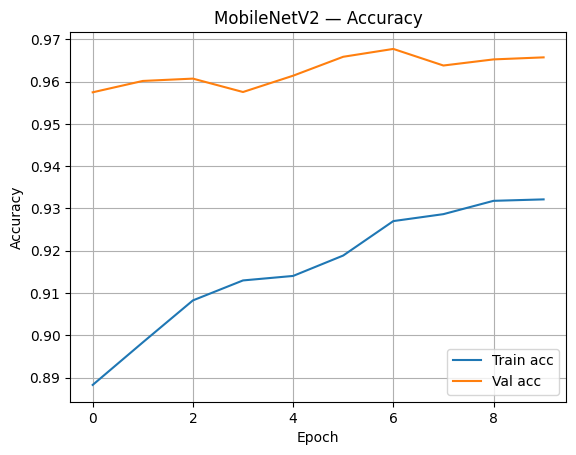

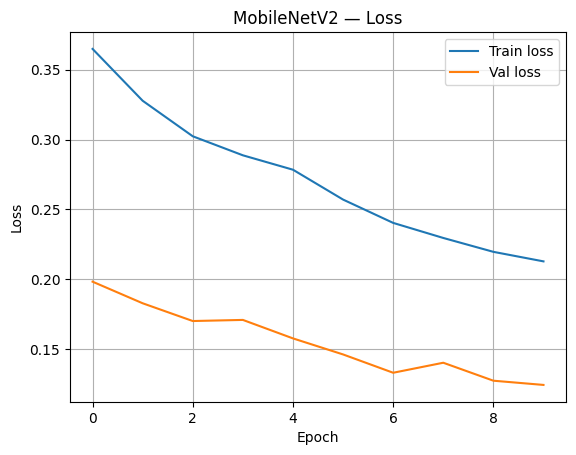

In [ ]:
import matplotlib.pyplot as plt

hist = history_mobilenet if 'history_mobilenet' in globals() else history_mobilenet_resume
H = hist.history

plt.figure()
plt.plot(H['accuracy'], label='Train acc')
plt.plot(H['val_accuracy'], label='Val acc')
plt.title('MobileNetV2 — Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)
plt.show()

plt.figure()
plt.plot(H['loss'], label='Train loss')
plt.plot(H['val_loss'], label='Val loss')
plt.title('MobileNetV2 — Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.show()

In [ ]:
test_loss_m, test_acc_m = mobilenet_model.evaluate(validation_generator, verbose=1)
print(f"[MobileNetV2] Test Accuracy: {test_acc_m:.4f} | Test Loss: {test_loss_m:.4f}")

454/454 ━━━━━━━━━━━━━━━━━━━━ 228s 500ms/step - accuracy: 0.9754 - loss: 0.1218
[MobileNetV2] Test Accuracy: 0.9677 | Test Loss: 0.1330


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Prédictions
Y_pred = mobilenet_model.predict(validation_generator, verbose=1)
y_pred = np.argmax(Y_pred, axis=1)





454/454 ━━━━━━━━━━━━━━━━━━━━ 236s 518ms/step


In [ ]:
# 2) Vérités terrain + labels
y_true = validation_generator.classes
class_labels = list(validation_generator.class_indices.keys())


In [ ]:

# 3) Rapport de classification
print(classification_report(y_true, y_pred, target_names=class_labels))

                           precision    recall  f1-score   support

                 Apple 10       0.93      0.98      0.96       231
                 Apple 11       1.00      1.00      1.00       142
                 Apple 12       0.97      1.00      0.99       154
                 Apple 13       1.00      0.99      0.99       231
                 Apple 14       0.91      0.94      0.92       154
                 Apple 17       0.94      0.96      0.95       243
                 Apple 18       0.99      0.93      0.96       162
                 Apple 19       0.99      1.00      1.00       241
                  Apple 5       0.97      0.99      0.98       146
                  Apple 7       1.00      1.00      1.00       229
                  Apple 8       0.94      0.95      0.94       228
                  Apple 9       0.98      0.99      0.99       231
             Apple Core 1       0.99      1.00      0.99        78
       Apple Red Yellow 2       1.00      0.98      0.99     

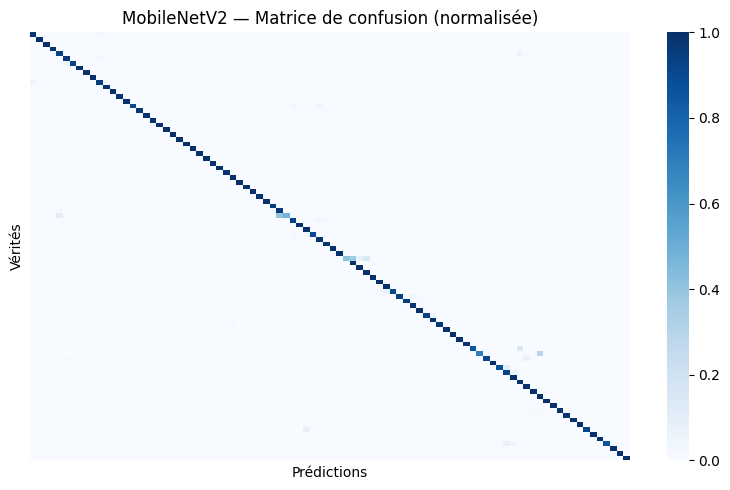

In [ ]:
# 4) Matrice de confusion (normalisée pour 90 classes, plus lisible)
cm = confusion_matrix(y_true, y_pred, normalize='true')

plt.figure(figsize=(8, 5))
sns.heatmap(cm, cmap="Blues", cbar=True, xticklabels=False, yticklabels=False)
plt.title("MobileNetV2 — Matrice de confusion (normalisée)")
plt.xlabel("Prédictions"); plt.ylabel("Vérités")
plt.tight_layout()
plt.show()

In [ ]:
import pickle, os
os.makedirs('/content/drive/MyDrive/fruit_project/models', exist_ok=True)
with open('/content/drive/MyDrive/fruit_project/models/history_mobilenet.pkl','wb') as f:
    pickle.dump(H, f)  # H est le dict d'historique utilisé plus haut

In [ ]:
# Imports
import os, pickle, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Assure-toi que validation_generator a bien shuffle=False
# validation_generator = val_datagen.flow_from_directory(..., shuffle=False)

# Dossiers de sortie (modifie si tu veux)
OUT_FIG   = "/content/drive/MyDrive/fruit_project/figures"
OUT_REP   = "/content/drive/MyDrive/fruit_project/reports"
os.makedirs(OUT_FIG, exist_ok=True)
os.makedirs(OUT_REP, exist_ok=True)

# Petit helper pour récupérer l'objet history, selon ton nom de variable
history = None
for name in ["history_mobilenet", "history_mobilenet_resume"]:
    if name in globals():
        history = globals()[name]
        print(f" Historique trouvé: {name}")
        break
if history is None:
    print("⚠ Aucun objet history en mémoire (pense à recharger ton .pkl si besoin).")

✅ Historique trouvé: history_mobilenet_resume


In [ ]:
if history is not None:
    h = history.history

    # Courbe Accuracy
    plt.figure()
    plt.plot(h.get('accuracy', []), label='Train Acc')
    plt.plot(h.get('val_accuracy', []), label='Val Acc')
    plt.title('Courbe de précision - MobileNet')
    plt.xlabel('Époques'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)
    acc_path = os.path.join(OUT_FIG, "courbe_accuracy_mobile.png")
    plt.savefig(acc_path, dpi=160); plt.close()
    print("Courbe accuracy sauvegardée ->", acc_path)

    # Courbe Loss
    plt.figure()
    plt.plot(h.get('loss', []), label='Train Loss')
    plt.plot(h.get('val_loss', []), label='Val Loss')
    plt.title('Courbe de perte - MobileNet')
    plt.xlabel('Époques'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
    loss_path = os.path.join(OUT_FIG, "courbe_loss_mobile.png")
    plt.savefig(loss_path, dpi=160); plt.close()
    print("Courbe loss sauvegardée ->", loss_path)

    # (Optionnel) sauvegarder l’historique au format pkl pour plus tard
    hist_pkl = os.path.join(OUT_REP, "history_mobile.pkl")
    with open(hist_pkl, "wb") as f:
        pickle.dump(h, f)
    print(" Historique sauvegardé (pkl) ->", hist_pkl)

📈 Courbe accuracy sauvegardée -> /content/drive/MyDrive/fruit_project/figures/courbe_accuracy_mobile.png
📉 Courbe loss sauvegardée -> /content/drive/MyDrive/fruit_project/figures/courbe_loss_mobile.png
💾 Historique sauvegardé (pkl) -> /content/drive/MyDrive/fruit_project/reports/history_mobile.pkl


In [ ]:
eval_txt = os.path.join(OUT_REP, "evaluation_mobile.txt")
test_loss, test_acc = mobilenet_model.evaluate(validation_generator, verbose=1)
with open(eval_txt, "w") as f:
    f.write(f"Accuracy (test/val) : {test_acc:.4f}\n")
    f.write(f"Loss (test/val)     : {test_loss:.4f}\n")
print(" Évaluation sauvegardée ->", eval_txt)

454/454 ━━━━━━━━━━━━━━━━━━━━ 233s 511ms/step - accuracy: 0.9754 - loss: 0.1218
✅ Évaluation sauvegardée -> /content/drive/MyDrive/fruit_project/reports/evaluation_mobile.txt


In [ ]:
# IMPORTANT: validation_generator doit avoir shuffle=False pour aligner y_true/y_pred
Y_pred = mobilenet_model.predict(validation_generator, verbose=1)
y_pred = np.argmax(Y_pred, axis=1)

# Étiquettes vraies + noms de classes
y_true = validation_generator.classes
class_labels = list(validation_generator.class_indices.keys())

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)






454/454 ━━━━━━━━━━━━━━━━━━━━ 227s 500ms/step


In [ ]:
# Heatmap (non normalisée)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap="Blues", xticklabels=False, yticklabels=False)
plt.title("Matrice de confusion - MobileNet")
plt.xlabel("Prédictions"); plt.ylabel("Vérités")
cm_png = os.path.join(OUT_FIG, "confusion_matrix_mobile.png")
plt.tight_layout(); plt.savefig(cm_png, dpi=170); plt.close()
print("Matrice de confusion sauvegardée ->", cm_png)

Matrice de confusion sauvegardée -> /content/drive/MyDrive/fruit_project/figures/confusion_matrix_mobile.png


In [ ]:
# (Optionnel) Matrice normalisée par ligne (rappel)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(14, 12))
sns.heatmap(cm_norm, cmap="Blues", xticklabels=False, yticklabels=False)
plt.title("Matrice de confusion normalisée - MobileNet")
plt.xlabel("Prédictions"); plt.ylabel("Vérités")
cmn_png = os.path.join(OUT_FIG, "confusion_matrix_normalized_mobile.png")
plt.tight_layout(); plt.savefig(cmn_png, dpi=170); plt.close()
print("Matrice normalisée sauvegardée ->", cmn_png)

Matrice normalisée sauvegardée -> /content/drive/MyDrive/fruit_project/figures/confusion_matrix_normalized_mobile.png


In [ ]:
# Rapport de classification (TXT)
report = classification_report(y_true, y_pred, target_names=class_labels, digits=4)
report_txt = os.path.join(OUT_REP, "classification_report_mobile.txt")
with open(report_txt, "w", encoding="utf-8") as f:
    f.write(report)
print("Rapport de classification sauvegardé ->", report_txt)

Rapport de classification sauvegardé -> /content/drive/MyDrive/fruit_project/reports/classification_report_mobile.txt


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mob_preprocess

test_dir = "/content/drive/MyDrive/fruits-360_100x100/Test"

# --- Pour le CNN (tes images 100x100 normalisées 0..1) ---
cnn_test_datagen = ImageDataGenerator(rescale=1./255)
cnn_val_gen = cnn_test_datagen.flow_from_directory(
    test_dir, target_size=(100, 100), batch_size=32,
    class_mode='categorical', shuffle=False
)

# --- Pour MobileNetV2 (attend 160x160 + preprocess_input) ---
mob_test_datagen = ImageDataGenerator(preprocessing_function=mob_preprocess)
mob_val_gen = mob_test_datagen.flow_from_directory(
    test_dir, target_size=(128, 128), batch_size=32,
    class_mode='categorical', shuffle=False
)

# Map index -> nom de classe (identique pour les deux)
idx_to_class = {v:k for k,v in cnn_val_gen.class_indices.items()}
class_labels = [idx_to_class[i] for i in range(len(idx_to_class))]

Found 14527 images belonging to 90 classes.
Found 14527 images belonging to 90 classes.


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam

cnn_model = load_model("/content/drive/MyDrive/models/fruit_model.h5")
cnn_model.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])

mobilenet_model = load_model("/content/drive/MyDrive/models/mobilenet_v2_best.h5")
mobilenet_model.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])



In [ ]:
print("=== Évaluation CNN ===")
cnn_loss, cnn_acc = cnn_model.evaluate(cnn_val_gen, verbose=1)
print(f"CNN  -> acc: {cnn_acc:.4f}  |  loss: {cnn_loss:.4f}")

print("\n=== Évaluation MobileNetV2 ===")
mob_loss, mob_acc = mobilenet_model.evaluate(mob_val_gen, verbose=1)
print(f"MobileNetV2 -> acc: {mob_acc:.4f}  |  loss: {mob_loss:.4f}")

=== Évaluation CNN ===


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


454/454 ━━━━━━━━━━━━━━━━━━━━ 118s 256ms/step - accuracy: 0.9815 - loss: 0.0585
CNN  -> acc: 0.9687  |  loss: 0.0859

=== Évaluation MobileNetV2 ===
454/454 ━━━━━━━━━━━━━━━━━━━━ 224s 485ms/step - accuracy: 0.9754 - loss: 0.1218
MobileNetV2 -> acc: 0.9677  |  loss: 0.1330


454/454 ━━━━━━━━━━━━━━━━━━━━ 120s 264ms/step

=== Rapport CNN ===
                           precision    recall  f1-score   support

                 Apple 10       0.98      0.99      0.99       231
                 Apple 11       0.99      1.00      1.00       142
                 Apple 12       0.97      0.97      0.97       154
                 Apple 13       0.98      1.00      0.99       231
                 Apple 14       1.00      1.00      1.00       154
                 Apple 17       1.00      1.00      1.00       243
                 Apple 18       1.00      1.00      1.00       162
                 Apple 19       0.98      1.00      0.99       241
                  Apple 5       1.00      1.00      1.00       146
                  Apple 7       1.00      0.99      0.99       229
                  Apple 8       0.99      0.98      0.99       228
                  Apple 9       0.93      1.00      0.96       231
             Apple Core 1       1.00      1.00      1.00      

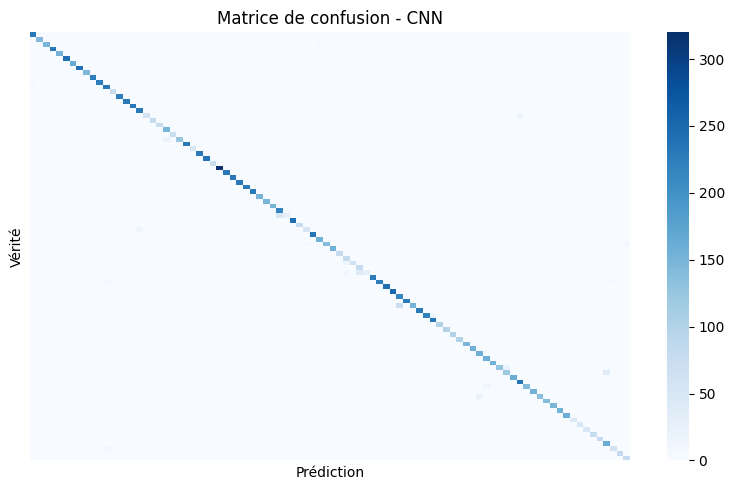

454/454 ━━━━━━━━━━━━━━━━━━━━ 225s 496ms/step

=== Rapport MobileNetV2 ===
                           precision    recall  f1-score   support

                 Apple 10       0.93      0.98      0.96       231
                 Apple 11       1.00      1.00      1.00       142
                 Apple 12       0.97      1.00      0.99       154
                 Apple 13       1.00      0.99      0.99       231
                 Apple 14       0.91      0.94      0.92       154
                 Apple 17       0.94      0.96      0.95       243
                 Apple 18       0.99      0.93      0.96       162
                 Apple 19       0.99      1.00      1.00       241
                  Apple 5       0.97      0.99      0.98       146
                  Apple 7       1.00      1.00      1.00       229
                  Apple 8       0.94      0.95      0.94       228
                  Apple 9       0.98      0.99      0.99       231
             Apple Core 1       0.99      1.00      0.

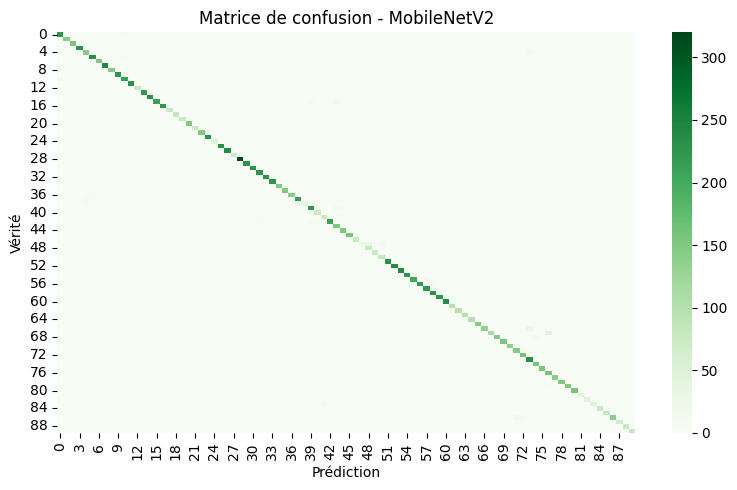

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns, matplotlib.pyplot as plt

# --- CNN ---
Y_pred_cnn = cnn_model.predict(cnn_val_gen, verbose=1)
y_pred_cnn = np.argmax(Y_pred_cnn, axis=1)
y_true = cnn_val_gen.classes

print("\n=== Rapport CNN ===")
print(classification_report(y_true, y_pred_cnn, target_names=class_labels, digits=2))

cm_cnn = confusion_matrix(y_true, y_pred_cnn)
plt.figure(figsize=(8,5))
sns.heatmap(cm_cnn, cmap="Blues", xticklabels= False, yticklabels= False)
plt.title("Matrice de confusion - CNN")
plt.xlabel("Prédiction")
plt.ylabel("Vérité")
plt.tight_layout()
plt.show()

# --- MobileNetV2 ---
Y_pred_mob = mobilenet_model.predict(mob_val_gen, verbose=1)
y_pred_mob = np.argmax(Y_pred_mob, axis=1)

print("\n=== Rapport MobileNetV2 ===")
print(classification_report(y_true, y_pred_mob, target_names=class_labels, digits=2))

cm_mob = confusion_matrix(y_true, y_pred_mob)
plt.figure(figsize=(8,5))
sns.heatmap(cm_mob, cmap="Greens")
plt.title("Matrice de confusion - MobileNetV2")
plt.xlabel("Prédiction")
plt.ylabel("Vérité")
plt.tight_layout()
plt.show()

In [ ]:
import time, math

def bench_inference(model, gen, max_images=2000):
    steps = math.ceil(min(max_images, gen.n) / gen.batch_size)
    t0 = time.time()
    _ = model.predict(gen, steps=steps, verbose=0)
    dt = time.time() - t0
    imgs = steps * gen.batch_size
    return imgs/dt, dt

cnn_ips, cnn_time = bench_inference(cnn_model, cnn_val_gen)
mob_ips, mob_time = bench_inference(mobilenet_model, mob_val_gen)

print(f"CNN  -> ~{cnn_ips:.1f} images/s  (sur ~{int(cnn_ips*cnn_time)} images, {cnn_time:.1f}s)")
print(f"MobileNetV2 -> ~{mob_ips:.1f} images/s  (sur ~{int(mob_ips*mob_time)} images, {mob_time:.1f}s)")

CNN  -> ~124.7 images/s  (sur ~2016 images, 16.2s)
MobileNetV2 -> ~65.4 images/s  (sur ~2016 images, 30.8s)


In [ ]:
def model_info(name, model):
    params = model.count_params()
    print(f"{name}: {params:,} paramètres")

model_info("CNN", cnn_model)
model_info("MobileNetV2", mobilenet_model)

CNN: 1,743,386 paramètres
MobileNetV2: 2,433,562 paramètres


In [ ]:
# 1) Recharger le meilleur modèle MobileNetV2 (tête déjà apprise)
from tensorflow.keras.models import load_model
mobilenet_model = load_model("mobilenet_v2_best.h5")



In [ ]:
# 2) Dégeler uniquement la fin du backbone (ex: de block_13 à la fin)
base = mobilenet_model.layers[0]  # MobileNetV2 est le bloc 0 du Sequential
for layer in base.layers:
    layer.trainable = False
for layer in base.layers:
    if "block_13" in layer.name or "block_14" in layer.name or "Conv_1" in layer.name:
        layer.trainable = True



In [ ]:
# 3) Re-compiler avec un très petit LR
from tensorflow.keras.optimizers import Adam
mobilenet_model.compile(optimizer=Adam(1e-5),
                        loss="categorical_crossentropy",
                        metrics=["accuracy"])


In [ ]:
# 4) Courte passe de fine-tuning (early stopping recommandé)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

ckpt  = ModelCheckpoint("mobilenet_v2_finetuned.h5", monitor="val_accuracy",
                        save_best_only=True, mode="max", verbose=1)
early = EarlyStopping(monitor="val_accuracy", patience=3,
                      restore_best_weights=True, verbose=1)
rlr   = ReduceLROnPlateau(monitor="val_loss", factor=0.3,
                          patience=2, min_lr=1e-6, verbose=1)

In [ ]:
history_ft = mobilenet_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    callbacks=[ckpt, early, rlr],
    verbose=1
)

Epoch 1/5
914/914 ━━━━━━━━━━━━━━━━━━━━ 0s 833ms/step - accuracy: 0.6546 - loss: 1.1980
Epoch 1: val_accuracy improved from -inf to 0.87754, saving model to mobilenet_v2_finetuned.h5


914/914 ━━━━━━━━━━━━━━━━━━━━ 1042s 1s/step - accuracy: 0.6547 - loss: 1.1976 - val_accuracy: 0.8775 - val_loss: 0.3630 - learning_rate: 1.0000e-05
Epoch 2/5
914/914 ━━━━━━━━━━━━━━━━━━━━ 0s 784ms/step - accuracy: 0.8606 - loss: 0.4334
Epoch 2: val_accuracy improved from 0.87754 to 0.95243, saving model to mobilenet_v2_finetuned.h5


914/914 ━━━━━━━━━━━━━━━━━━━━ 949s 1s/step - accuracy: 0.8606 - loss: 0.4334 - val_accuracy: 0.9524 - val_loss: 0.1603 - learning_rate: 1.0000e-05
Epoch 3/5
914/914 ━━━━━━━━━━━━━━━━━━━━ 0s 808ms/step - accuracy: 0.8970 - loss: 0.3134
Epoch 3: val_accuracy improved from 0.95243 to 0.97102, saving model to mobilenet_v2_finetuned.h5


914/914 ━━━━━━━━━━━━━━━━━━━━ 968s 1s/step - accuracy: 0.8970 - loss: 0.3134 - val_accuracy: 0.9710 - val_loss: 0.1098 - learning_rate: 1.0000e-05
Epoch 4/5
914/914 ━━━━━━━━━━━━━━━━━━━━ 0s 853ms/step - accuracy: 0.9158 - loss: 0.2616
Epoch 4: val_accuracy improved from 0.97102 to 0.98128, saving model to mobilenet_v2_finetuned.h5


914/914 ━━━━━━━━━━━━━━━━━━━━ 999s 1s/step - accuracy: 0.9158 - loss: 0.2615 - val_accuracy: 0.9813 - val_loss: 0.0787 - learning_rate: 1.0000e-05
Epoch 5/5
914/914 ━━━━━━━━━━━━━━━━━━━━ 0s 812ms/step - accuracy: 0.9292 - loss: 0.2213
Epoch 5: val_accuracy improved from 0.98128 to 0.98465, saving model to mobilenet_v2_finetuned.h5


914/914 ━━━━━━━━━━━━━━━━━━━━ 971s 1s/step - accuracy: 0.9292 - loss: 0.2213 - val_accuracy: 0.9846 - val_loss: 0.0653 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 5.


In [ ]:
from tensorflow.keras.models import load_model
best_mobilenet = load_model("mobilenet_v2_finetuned.h5")  # mets le bon nom si différent

In [ ]:
test_loss, test_acc = best_mobilenet.evaluate(validation_generator, verbose=1)
print(f"MobileNetV2 — Accuracy: {test_acc:.4f} | Loss: {test_loss:.4f}")

454/454 ━━━━━━━━━━━━━━━━━━━━ 233s 502ms/step - accuracy: 0.9868 - loss: 0.0621
MobileNetV2 — Accuracy: 0.9846 | Loss: 0.0653


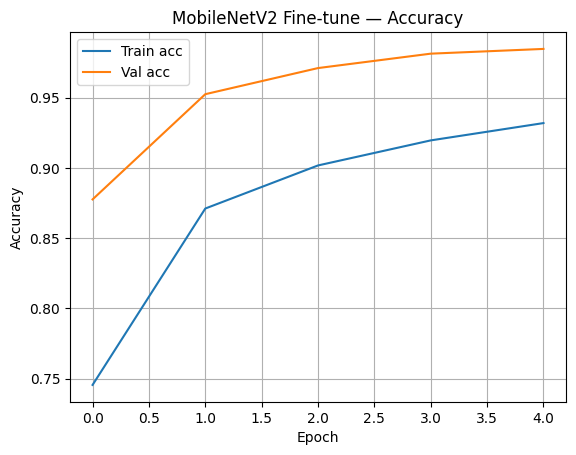

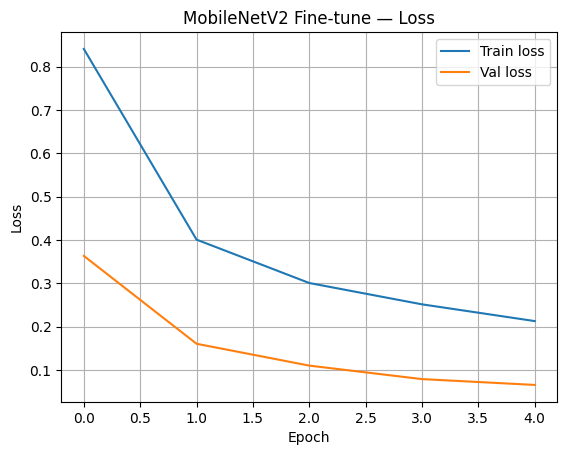

In [ ]:
import matplotlib.pyplot as plt

# Utilise l'historique chargé
H = history_ft_loaded

plt.figure()
plt.plot(H['accuracy'], label='Train acc')
plt.plot(H['val_accuracy'], label='Val acc')
plt.title('MobileNetV2 Fine-tune — Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)
plt.show()

plt.figure()
plt.plot(H['loss'], label='Train loss')
plt.plot(H['val_loss'], label='Val loss')
plt.title('MobileNetV2 Fine-tune — Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# IMPORTANT: validation_generator doit avoir shuffle=False
Y_prob = best_mobilenet.predict(validation_generator, verbose=1)
y_pred = np.argmax(Y_prob, axis=1)

y_true = validation_generator.classes
class_labels = list(validation_generator.class_indices.keys())



454/454 ━━━━━━━━━━━━━━━━━━━━ 232s 504ms/step


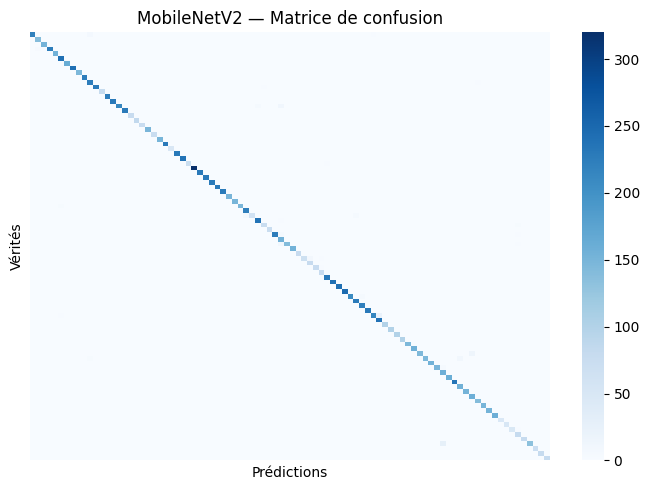

In [ ]:
# Matrice de confusion (option: normalisée)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, cmap="Blues", xticklabels=False, yticklabels=False)
plt.title("MobileNetV2 — Matrice de confusion")
plt.xlabel("Prédictions"); plt.ylabel("Vérités")
plt.tight_layout(); plt.show()



In [ ]:
# Rapport de classification
print(classification_report(y_true, y_pred, target_names=class_labels, digits=4))

                           precision    recall  f1-score   support

                 Apple 10     0.9955    0.9567    0.9757       231
                 Apple 11     0.9722    0.9859    0.9790       142
                 Apple 12     0.9808    0.9935    0.9871       154
                 Apple 13     1.0000    0.9740    0.9868       231
                 Apple 14     1.0000    1.0000    1.0000       154
                 Apple 17     0.9718    0.9918    0.9817       243
                 Apple 18     0.9878    1.0000    0.9939       162
                 Apple 19     0.9959    1.0000    0.9979       241
                  Apple 5     0.9799    1.0000    0.9898       146
                  Apple 7     1.0000    0.9869    0.9934       229
                  Apple 8     0.9494    0.9868    0.9677       228
                  Apple 9     0.9957    0.9913    0.9935       231
             Apple Core 1     1.0000    1.0000    1.0000        78
       Apple Red Yellow 2     0.9956    1.0000    0.9978     

In [ ]:
import pickle, os

history_path = "/content/drive/MyDrive/fruit_project/models/history_mobilenet_finetune.pkl"

with open(history_path, 'wb') as f:
    pickle.dump(history_mobilenet.history, f)

print("Historique sauvegardé ->", history_path)

NameError: name 'history_mobilenet' is not defined

In [ ]:
import pickle
import os

# Chemin de sauvegarde (adapter à ton dossier Drive)
history_path = "/content/drive/MyDrive/fruit_project/models/history_mobilenet_finetune.pkl"

# Assure-toi que le dossier existe
os.makedirs(os.path.dirname(history_path), exist_ok=True)

# Sauvegarde l'historique de la variable history_ft
with open(history_path, 'wb') as f:
    pickle.dump(history_ft.history, f)

print("Historique sauvegardé ->", history_path)

Historique sauvegardé -> /content/drive/MyDrive/fruit_project/models/history_mobilenet_finetune.pkl


In [ ]:
print("== Résumé comparaison ==")
print(f"CNN (baseline)  : acc_test ~ {cnn_acc:.4f}")      # remplace par ta valeur CNN (ex: 0.9687)
print(f"MobileNetV2 FT  : acc_test ~ {test_acc:.4f}")          # valeur calculée ci-dessus

== Résumé comparaison ==
CNN (baseline)  : acc_test ~ 0.9687
MobileNetV2 FT  : acc_test ~ 0.9846


In [ ]:
# Format Keras moderne (préféré à .h5)
best_mobilenet.save("/content/drive/MyDrive/fruit_project/models/mobilenet_v2_finetuned.keras")
# Optionnel: exporter aussi en .h5 si tu veux
best_mobilenet.save("/content/drive/MyDrive/fruit_project/models/mobilenet_v2_finetuned.h5")

In [ ]:
import pickle
import os

# Chemin du fichier historique sauvegardé (adapter à ton dossier Drive)
history_path = "/content/drive/MyDrive/fruit_project/models/history_mobilenet_finetune.pkl"

# Charger l'historique
with open(history_path, 'rb') as f:
    history_ft_loaded = pickle.load(f)

print("Historique de fine-tuning chargé avec succès.")

Historique de fine-tuning chargé avec succès.


In [ ]:
from tensorflow.keras.models import load_model
best_mobilenet = load_model("/content/drive/MyDrive/fruit_project/models/mobilenet_v2_finetuned.h5")

In [ ]:
loss, acc = mobilenet_model.evaluate(validation_generator)
print(f"MobileNetV2 - Accuracy: {acc:.4f} | Loss: {loss:.4f}")

NameError: name 'mobilenet_model' is not defined

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mob_preprocess

test_dir = "/content/drive/MyDrive/fruits-360_100x100/Test"

# --- Pour le CNN (tes images 100x100 normalisées 0..1) ---
cnn_test_datagen = ImageDataGenerator(rescale=1./255)
cnn_val_gen = cnn_test_datagen.flow_from_directory(
    test_dir, target_size=(100, 100), batch_size=32,
    class_mode='categorical', shuffle=False
)

# --- Pour MobileNetV2 (attend 160x160 + preprocess_input) ---
mob_test_datagen = ImageDataGenerator(preprocessing_function=mob_preprocess)
mob_val_gen = mob_test_datagen.flow_from_directory(
    test_dir, target_size=(128, 128), batch_size=32,
    class_mode='categorical', shuffle=False
)
# --- Pour MobileNetV2finetuning
mobft_val_gen = mob_test_datagen.flow_from_directory(
    test_dir, target_size=(128, 128), batch_size=32,
    class_mode='categorical', shuffle=False
)
# Map index -> nom de classe (identique pour les deux)
idx_to_class = {v:k for k,v in cnn_val_gen.class_indices.items()}
class_labels = [idx_to_class[i] for i in range(len(idx_to_class))]

Found 14527 images belonging to 90 classes.
Found 14527 images belonging to 90 classes.
Found 14527 images belonging to 90 classes.


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam

cnn_model = load_model("/content/drive/MyDrive/models/fruit_model.h5")
cnn_model.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])

mobilenet_model = load_model("/content/drive/MyDrive/models/mobilenet_v2_best.h5")
mobilenet_model.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])

mobilenet_ft_model = load_model("/content/drive/MyDrive/models/mobilenet_v2_finetuned.h5")
mobilenet_ft_model.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])


In [ ]:
print("=== Évaluation CNN ===")
cnn_loss, cnn_acc = cnn_model.evaluate(cnn_val_gen, verbose=1)
print(f"CNN  -> acc: {cnn_acc:.4f}  |  loss: {cnn_loss:.4f}")

print("\n=== Évaluation MobileNetV2 ===")
mob_loss, mob_acc = mobilenet_model.evaluate(mob_val_gen, verbose=1)
print(f"MobileNetV2 -> acc: {mob_acc:.4f}  |  loss: {mob_loss:.4f}")

print("\n=== Évaluation MobileNetV2 Finetuned ===")
mobft_loss, mobft_acc = mobilenet_ft_model.evaluate(mobft_val_gen, verbose=1)
print(f"MobileNetV2 FT -> acc: {mobft_acc:.4f}  |  loss: {mobft_loss:.4f}")

=== Évaluation CNN ===
454/454 ━━━━━━━━━━━━━━━━━━━━ 4721s 10s/step - accuracy: 0.9815 - loss: 0.0585
CNN  -> acc: 0.9687  |  loss: 0.0859

=== Évaluation MobileNetV2 ===
454/454 ━━━━━━━━━━━━━━━━━━━━ 66s 117ms/step - accuracy: 0.9754 - loss: 0.1218
MobileNetV2 -> acc: 0.9677  |  loss: 0.1330

=== Évaluation MobileNetV2 Finetuned ===
454/454 ━━━━━━━━━━━━━━━━━━━━ 53s 103ms/step - accuracy: 0.9868 - loss: 0.0621
MobileNetV2 FT -> acc: 0.9846  |  loss: 0.0653


454/454 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step

=== Rapport CNN ===
                           precision    recall  f1-score   support

                 Apple 10       0.98      0.99      0.99       231
                 Apple 11       0.99      1.00      1.00       142
                 Apple 12       0.97      0.97      0.97       154
                 Apple 13       0.98      1.00      0.99       231
                 Apple 14       1.00      1.00      1.00       154
                 Apple 17       1.00      1.00      1.00       243
                 Apple 18       1.00      1.00      1.00       162
                 Apple 19       0.98      1.00      0.99       241
                  Apple 5       1.00      1.00      1.00       146
                  Apple 7       1.00      0.99      0.99       229
                  Apple 8       0.99      0.98      0.99       228
                  Apple 9       0.93      1.00      0.96       231
             Apple Core 1       1.00      1.00      1.00        

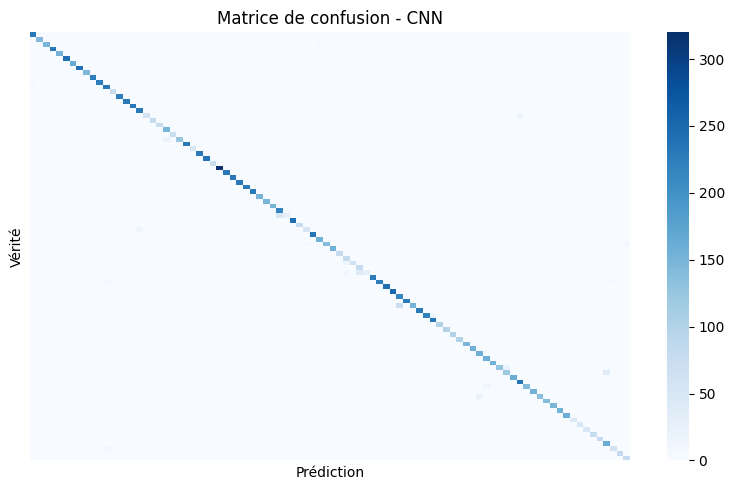

454/454 ━━━━━━━━━━━━━━━━━━━━ 51s 103ms/step

=== Rapport MobileNetV2 ===
                           precision    recall  f1-score   support

                 Apple 10       0.93      0.98      0.96       231
                 Apple 11       1.00      1.00      1.00       142
                 Apple 12       0.97      1.00      0.99       154
                 Apple 13       1.00      0.99      0.99       231
                 Apple 14       0.91      0.94      0.92       154
                 Apple 17       0.94      0.96      0.95       243
                 Apple 18       0.99      0.93      0.96       162
                 Apple 19       0.99      1.00      1.00       241
                  Apple 5       0.97      0.99      0.98       146
                  Apple 7       1.00      1.00      1.00       229
                  Apple 8       0.94      0.95      0.94       228
                  Apple 9       0.98      0.99      0.99       231
             Apple Core 1       0.99      1.00      0.9

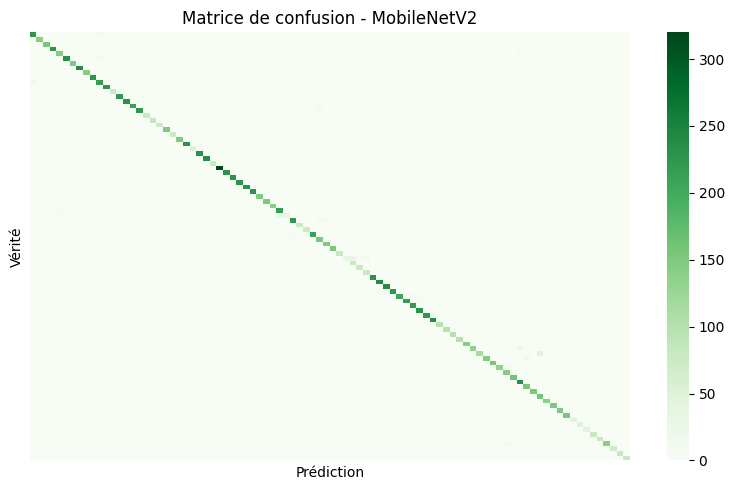

454/454 ━━━━━━━━━━━━━━━━━━━━ 50s 101ms/step

=== Rapport MobileNetV2 (fine-tuning) ===
                           precision    recall  f1-score   support

                 Apple 10       1.00      0.96      0.98       231
                 Apple 11       0.97      0.99      0.98       142
                 Apple 12       0.98      0.99      0.99       154
                 Apple 13       1.00      0.97      0.99       231
                 Apple 14       1.00      1.00      1.00       154
                 Apple 17       0.97      0.99      0.98       243
                 Apple 18       0.99      1.00      0.99       162
                 Apple 19       1.00      1.00      1.00       241
                  Apple 5       0.98      1.00      0.99       146
                  Apple 7       1.00      0.99      0.99       229
                  Apple 8       0.95      0.99      0.97       228
                  Apple 9       1.00      0.99      0.99       231
             Apple Core 1       1.00     

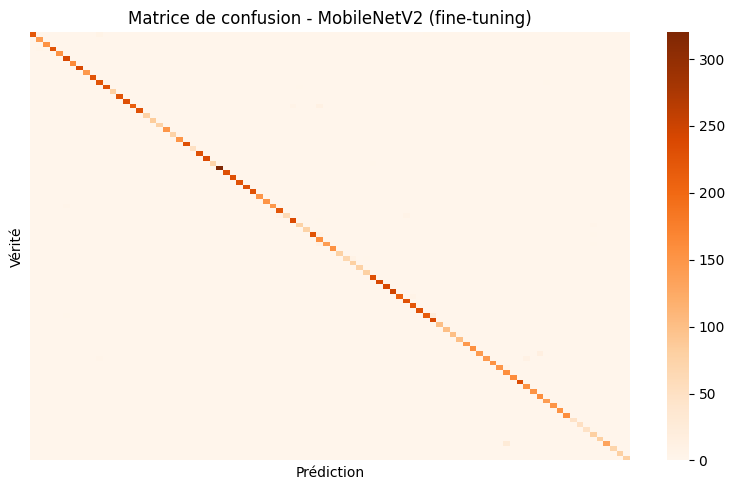

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns, matplotlib.pyplot as plt

# === CNN ===
Y_pred_cnn = cnn_model.predict(cnn_val_gen, verbose=1)
y_pred_cnn = np.argmax(Y_pred_cnn, axis=1)
y_true_cnn = cnn_val_gen.classes

print("\n=== Rapport CNN ===")
print(classification_report(y_true_cnn, y_pred_cnn,
                            target_names=class_labels, digits=2))

cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
plt.figure(figsize=(8,5))
sns.heatmap(cm_cnn, cmap="Blues", xticklabels=False, yticklabels=False)
plt.title("Matrice de confusion - CNN")
plt.xlabel("Prédiction")
plt.ylabel("Vérité")
plt.tight_layout()
plt.show()

# === MobileNetV2 (tête gelée) ===
Y_pred_mob = mobilenet_model.predict(mob_val_gen, verbose=1)
y_pred_mob = np.argmax(Y_pred_mob, axis=1)
y_true_mob = mob_val_gen.classes

print("\n=== Rapport MobileNetV2 ===")
print(classification_report(y_true_mob, y_pred_mob,
                            target_names=class_labels, digits=2))

cm_mob = confusion_matrix(y_true_mob, y_pred_mob)
plt.figure(figsize=(8,5))
sns.heatmap(cm_mob, cmap="Greens", xticklabels=False, yticklabels=False)
plt.title("Matrice de confusion - MobileNetV2")
plt.xlabel("Prédiction")
plt.ylabel("Vérité")
plt.tight_layout()
plt.show()

# === MobileNetV2 (fine-tuning) ===
Y_pred_mobft = mobilenet_ft_model.predict(mobft_val_gen, verbose=1)
y_pred_mobft = np.argmax(Y_pred_mobft, axis=1)
y_true_mobft = mobft_val_gen.classes

print("\n=== Rapport MobileNetV2 (fine-tuning) ===")
print(classification_report(y_true_mobft, y_pred_mobft,
                            target_names=class_labels, digits=2))

cm_mobft = confusion_matrix(y_true_mobft, y_pred_mobft)
plt.figure(figsize=(8,5))
sns.heatmap(cm_mobft, cmap="Oranges", xticklabels=False, yticklabels=False)
plt.title("Matrice de confusion - MobileNetV2 (fine-tuning)")
plt.xlabel("Prédiction")
plt.ylabel("Vérité")
plt.tight_layout()
plt.show()


In [ ]:
import time, math

def bench_inference(model, gen, max_images=2000):
    steps = math.ceil(min(max_images, gen.n) / gen.batch_size)
    t0 = time.time()
    _ = model.predict(gen, steps=steps, verbose=0)
    dt = time.time() - t0
    imgs = steps * gen.batch_size
    return imgs/dt, dt, imgs

# CNN
cnn_ips, cnn_time, cnn_imgs = bench_inference(cnn_model, cnn_val_gen)
print(f"CNN -> ~{cnn_ips:.1f} images/s  (sur {cnn_imgs} images, {cnn_time:.1f}s)")

# MobileNetV2 (tête gelée)
mob_ips, mob_time, mob_imgs = bench_inference(mobilenet_model, mob_val_gen)
print(f"MobileNetV2 -> ~{mob_ips:.1f} images/s  (sur {mob_imgs} images, {mob_time:.1f}s)")

# MobileNetV2 (fine-tuning)
mobft_ips, mobft_time, mobft_imgs = bench_inference(mobilenet_ft_model, mobft_val_gen)
print(f"MobileNetV2 FT -> ~{mobft_ips:.1f} images/s  (sur {mobft_imgs} images, {mobft_time:.1f}s)")


CNN -> ~338.8 images/s  (sur 2016 images, 6.0s)
MobileNetV2 -> ~193.2 images/s  (sur 2016 images, 10.4s)
MobileNetV2 FT -> ~193.4 images/s  (sur 2016 images, 10.4s)


In [ ]:
import numpy as np

def model_info(name, model):
    total = model.count_params()
    trainable = int(np.sum([np.prod(w.shape) for w in model.trainable_weights]))
    non_trainable = int(np.sum([np.prod(w.shape) for w in model.non_trainable_weights]))
    print(f"\n=== {name} ===")
    print(f"Paramètres totaux       : {total:,}")
    print(f"Paramètres entraînables : {trainable:,}")
    print(f"Paramètres gelés        : {non_trainable:,}")

# Utilisation
model_info("CNN", cnn_model)
model_info("MobileNetV2 (tête gelée)", mobilenet_model)
model_info("MobileNetV2 (fine-tuning)", mobilenet_ft_model)



=== CNN ===
Paramètres totaux       : 1,743,386
Paramètres entraînables : 1,743,386
Paramètres gelés        : 0

=== MobileNetV2 (tête gelée) ===
Paramètres totaux       : 2,433,562
Paramètres entraînables : 175,578
Paramètres gelés        : 2,257,984

=== MobileNetV2 (fine-tuning) ===
Paramètres totaux       : 2,433,562
Paramètres entraînables : 1,063,002
Paramètres gelés        : 1,370,560


In [ ]:
# Sauvegarde du modèle fine-tuné au format Keras
best_mobilenet.save("/content/drive/MyDrive/models/mobilenet_v2_finetuned.keras")

print("Modèle fine-tuné MobileNetV2 sauvegardé au format .keras")

Modèle fine-tuné MobileNetV2 sauvegardé au format .keras


In [ ]:
from tensorflow.keras.models import load_model
# Load the best MobileNetV2 model (fine-tuned)
best_mobilenet = load_model("/content/drive/MyDrive/models/mobilenet_v2_finetuned.keras", compile=False)

# Export to TensorFlow SavedModel format (folder)
export_dir = "/content/drive/MyDrive/models/mobilenet_v2_finetuned_savedmodel"
best_mobilenet.export(export_dir)
print("Exported to:", export_dir)

Saved artifact at '/content/drive/MyDrive/models/mobilenet_v2_finetuned_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 90), dtype=tf.float32, name=None)
Captures:
  134746377420624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134746377419280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134746377419472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134746377419856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134746377418704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134746377419664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134746377417936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134746377418128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134746377418896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134746377417360: TensorSpec(shape=(

In [ ]:
import os, json, numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns, matplotlib.pyplot as plt



# Adapte ces chemins à ton Drive
train_dir = "/content/drive/MyDrive/fruits-360_100x100/Training"   # <-- mets ton dossier train
test_dir  = "/content/drive/MyDrive/fruits-360_100x100/Test"       # <-- mets ton dossier test
save_dir  = "/content/drive/MyDrive/models"
os.makedirs(save_dir, exist_ok=True)

# Fichiers de sortie
H5_PATH     = os.path.join(save_dir, "fruit_model_improved.h5")
KERAS_PATH  = os.path.join(save_dir, "fruit_model_improved.keras")
CLASSES_JSON = os.path.join(save_dir, "classes.json")   # déjà existant normalement

In [ ]:
IMG_SIZE = 128
BATCH    = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.25,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    channel_shift_range=15,
    fill_mode='nearest'
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    class_mode='categorical'
)

val_datagen = ImageDataGenerator(rescale=1./255)
validation_generator = val_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    class_mode='categorical',
    shuffle=False    # important pour y_true / y_pred
)

num_classes = train_generator.num_classes
class_indices = train_generator.class_indices  # {class_name: idx}
idx_to_class = {v:k for k,v in class_indices.items()}
print("Classes :", num_classes)
list(idx_to_class.items())[:5]

Found 29222 images belonging to 90 classes.
Found 14527 images belonging to 90 classes.
Classes : 90


[(0, 'Apple 10'),
 (1, 'Apple 11'),
 (2, 'Apple 12'),
 (3, 'Apple 13'),
 (4, 'Apple 14')]

In [ ]:
def block(x, f):
    x = layers.SeparableConv2D(f, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.SeparableConv2D(f, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.MaxPool2D()(x)
    x = layers.Dropout(0.2)(x)
    return x

def build_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), n_classes=num_classes):
    x_in = layers.Input(shape=input_shape)
    x = block(x_in, 32)
    x = block(x, 64)
    x = block(x, 128)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.35)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    return models.Model(x_in, out)

model = build_cnn()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 128, 128, 32)   │           123 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 128, 128, 32)   │         1,312 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 64, 64, 64)     │         2,336 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_3              │ (None, 64, 64, 64)     │         4,672 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_4              │ (None, 32, 32, 128)    │         8,768 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 32, 32, 128)    │             

 Total params: 48,149 (188.08 KB)

 Trainable params: 47,253 (184.58 KB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:

loss = keras.losses.CategoricalCrossentropy(label_smoothing=0.05)
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=loss,
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=3, name="top3")]
)

ckpt  = ModelCheckpoint(H5_PATH, monitor="val_accuracy", save_best_only=True, mode="max", verbose=1)
early = EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True, verbose=1)
rlr   = ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-6, verbose=1)

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[ckpt, early, rlr],
    verbose=1
)

# Sauvegarde au format Keras v3
model.save(KERAS_PATH)
print("Models saved to:", H5_PATH, "and", KERAS_PATH)


NameError: name 'keras' is not defined